# Winter HAB Analysis: Exploratory Data Analysis

I am compiling surface temperature, salinity, and cell count data for two bloom-forming dinoflagellates, Heterocapsa triquetra and Prorocentrum minimum, from 6 Chesapeake Bay Program (CBP) monitoring locations across the Upper, Middle, and Lower Bay over roughly 40 years (1984–2026). The goal is to describe when and under what temperature and salinity conditions these species bloom.

This notebook starts from two separate compiled CBP downloads (phytoplankton counts and water quality), combines them into a single surface-layer dataset with one row per station per sampling date.

Data sets: 
Phytoplankton data: https://datahub.chesapeakebay.net/Home/LivingResources
T/S data: https://datahub.chesapeakebay.net/Home/WaterQuality

Using 2 stations from each part of the Bay (Upper, Middle, and Lower): CB1.1, CB2.2, CB4.3C, CB5.2, WE4.2, and LE5.5/LE5.5-W (same station, just different names). Originally, three other lower bay stations were downloaded, but their data did not extend the entire time series, so they were later omitted (CB6.1, SBE2, SBE5).

In [1]:
# importing packages and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 110

DATA_DIR = '../Data'
PHYTO_FILE = f'{DATA_DIR}/CompiledPhytoplanktonData.xlsx'
TS_FILE = f'{DATA_DIR}/CompiledTSData.xlsx'
OUT_FILE = f'{DATA_DIR}/hab_surface_compiled.csv'

## Load the two raw compiled datasets

Both files are long-format CBP downloads: one row per measurement. The phytoplankton file has one row per taxon per sample, and the water quality file has one row per parameter (temperature or salinity) per sampling depth.

In [2]:
phyto_raw = pd.read_excel(PHYTO_FILE)
ts_raw = pd.read_excel(TS_FILE)

print('Phytoplankton rows:', len(phyto_raw), '| columns:', phyto_raw.shape[1])
print('Temp/salinity rows:', len(ts_raw), '| columns:', ts_raw.shape[1])
print('Phytoplankton stations:', sorted(phyto_raw['Station'].unique()))
print('Temp/salinity stations:', sorted(ts_raw['Station'].unique()))

Phytoplankton rows: 160892 | columns: 26
Temp/salinity rows: 105306 | columns: 29
Phytoplankton stations: ['CB1.1', 'CB2.2', 'CB4.3C', 'CB5.2', 'CB6.1', 'LE5.5', 'LE5.5-W', 'SBE2', 'SBE5', 'WE4.2']
Temp/salinity stations: ['CB1.1', 'CB2.2', 'CB4.3C', 'CB5.2', 'LE5.5', 'LE5.5-W', 'WE4.2']


## Compile the data
Remove exact duplicate rows from each raw file.

Keep the six study locations. LE5.5 was relocated and renamed LE5.5-W in 2004, so the six locations are represented by seven station codes. The extra stations in the phytoplankton download (CB6.1, SBE2, SBE5) have no matching temperature/salinity data and are dropped.

Restrict to the surface layer, or as close as possible.

Temperature/salinity: for each station and date, keep the shallowest sampling depth.
Phytoplankton: CBP does not collect true surface phytoplankton samples at most stations. Each sampling event has one near-surface sample, which is either a composite from above the pycnocline (AP), a whole-water-column composite at the shallow Upper Bay stations (WC), or occasionally a true surface sample (S). Keep that one sample and drop the below-pycnocline (BP) samples.

Build species counts. For each sample I take the total H. triquetra and P. minimum abundance (cells/L). If a sample was counted but a species was not recorded, its abundance is set to 0.

Merge on station and date, keeping only dates where both phytoplankton and temperature/salinity data exist.

In [3]:
# Exact duplicates in the raw files
n_p, n_t = len(phyto_raw), len(ts_raw)
phyto = phyto_raw.drop_duplicates().copy()
ts = ts_raw.drop_duplicates().copy()
print(f'Phytoplankton duplicates removed: {n_p - len(phyto)}')
print(f'Temp/salinity duplicates removed: {n_t - len(ts)}')

# Study stations and regions
REGION = {'CB1.1': 'Upper Bay', 'CB2.2': 'Upper Bay',
          'CB4.3C': 'Middle Bay', 'CB5.2': 'Middle Bay',
          'WE4.2': 'Lower Bay', 'LE5.5': 'Lower Bay', 'LE5.5-W': 'Lower Bay'}
STATIONS = list(REGION)
phyto = phyto[phyto['Station'].isin(STATIONS)]
ts = ts[ts['Station'].isin(STATIONS)]
for d in (phyto, ts):
    d['SampleDate'] = pd.to_datetime(d['SampleDate']).dt.normalize()

Phytoplankton duplicates removed: 0
Temp/salinity duplicates removed: 0


In [4]:
# Temperature and salinity data - only keeping the shallowest measurement per date
ts = ts[ts['Parameter'].isin(['WTEMP', 'SALINITY'])]
min_depth = ts.groupby(['Station', 'SampleDate'])['SampleDepthM'].transform('min')
ts_surf = ts[ts['SampleDepthM'] == min_depth]

ts_wide = (ts_surf
           .pivot_table(index=['Station', 'SampleDate'], columns='Parameter',
                        values='MeasureValue', aggfunc='mean')
           .rename(columns={'WTEMP': 'Temperature_C', 'SALINITY': 'Salinity_ppt'})
           .reset_index())
depths = ts_surf.groupby(['Station', 'SampleDate'])['SampleDepthM'].first().rename('TS_Depth_m')
ts_wide = ts_wide.merge(depths.reset_index(), on=['Station', 'SampleDate'])
ts_wide.columns.name = None

print('Surface T/S station-dates:', len(ts_wide))
print('Surface sampling depths used (m):')
print(ts_wide['TS_Depth_m'].value_counts().sort_index())

Surface T/S station-dates: 3885
Surface sampling depths used (m):
TS_Depth_m
0.0       51
0.2        1
0.5     2695
1.0     1135
1.1        1
2.0        1
10.0       1
Name: count, dtype: int64


In [5]:
# Phytoplankton data - keeping the closest to the surface measurement per date (S > AP > WC; drop BP)
LAYER_PRIORITY = {'S': 0, 'AP': 1, 'WC': 2}
phyto = phyto[phyto['Layer'].isin(LAYER_PRIORITY)].copy()
phyto['layer_rank'] = phyto['Layer'].map(LAYER_PRIORITY)
best = phyto.groupby(['Station', 'SampleDate'])['layer_rank'].transform('min')
phyto_surf = phyto[phyto['layer_rank'] == best]

# One row per sampling event (with station coordinates and the layer used)
events = (phyto_surf.groupby(['Station', 'SampleDate'])
          .agg(Latitude=('Latitude', 'first'), Longitude=('Longitude', 'first'),
               Phyto_Layer=('Layer', 'first'))
          .reset_index())
print('Near-surface phytoplankton events:', len(events))
print(events['Phyto_Layer'].value_counts())

Near-surface phytoplankton events: 2431
Phyto_Layer
AP    1927
WC     502
S        2
Name: count, dtype: int64


In [6]:
# Species abundance per event (cells/L); absent in a counted sample = 0
SPECIES = {'Heterocapsa triquetra': 'H_triquetra_cells_L',
           'Prorocentrum minimum': 'P_minimum_cells_L'}
sp = phyto_surf[phyto_surf['ScientificName'].isin(SPECIES)]

# sum within a replicate (some early records split a species across entries),
# then average across replicates
counts = (sp.groupby(['Station', 'SampleDate', 'SampleReplicate', 'ScientificName'])['MeasureValue'].sum()
            .groupby(['Station', 'SampleDate', 'ScientificName']).mean()
            .unstack('ScientificName')
            .rename(columns=SPECIES)
            .reset_index())
counts.columns.name = None

phyto_events = events.merge(counts, on=['Station', 'SampleDate'], how='left')
phyto_events[list(SPECIES.values())] = phyto_events[list(SPECIES.values())].fillna(0)
phyto_events.head()

,Station,SampleDate,Latitude,Longitude,Phyto_Layer,H_triquetra_cells_L,P_minimum_cells_L
0,CB1.1,1984-08-07,39.54794,-76.08481,AP,0.0,0.0
1,CB1.1,1984-09-12,39.54794,-76.08481,AP,0.0,0.0
2,CB1.1,1984-09-26,39.54794,-76.08481,AP,0.0,0.0
3,CB1.1,1984-10-10,39.54794,-76.08481,AP,0.0,0.0
4,CB1.1,1984-11-07,39.54794,-76.08481,AP,0.0,0.0


In [7]:
# Merge, keeping only dates with both datasets
df = phyto_events.merge(ts_wide, on=['Station', 'SampleDate'], how='inner')
df = df.dropna(subset=['Temperature_C', 'Salinity_ppt'], how='all')

df['Region'] = df['Station'].map(REGION)
df['Year'] = df['SampleDate'].dt.year
df['Month'] = df['SampleDate'].dt.month
df['Season'] = df['Month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                3: 'Spring', 4: 'Spring', 5: 'Spring',
                                6: 'Summer', 7: 'Summer', 8: 'Summer',
                                9: 'Fall', 10: 'Fall', 11: 'Fall'})

cols = ['Station', 'Region', 'Latitude', 'Longitude', 'SampleDate', 'Year', 'Month', 'Season',
        'Temperature_C', 'Salinity_ppt', 'TS_Depth_m', 'Phyto_Layer',
        'H_triquetra_cells_L', 'P_minimum_cells_L']
df = df[cols].sort_values(['Station', 'SampleDate']).reset_index(drop=True)

print(f'Phytoplankton events: {len(phyto_events)} | Surface T/S events: {len(ts_wide)} | '
      f'Matched (both): {len(df)}')

# Check for duplicates one more time
print('Duplicate station-dates in final table:', df.duplicated(['Station', 'SampleDate']).sum())
print('Fully duplicated rows in final table:', df.duplicated().sum())

df.to_csv(OUT_FILE, index=False)
print('Saved', OUT_FILE)
df.head()

Phytoplankton events: 2431 | Surface T/S events: 3885 | Matched (both): 2272
Duplicate station-dates in final table: 0
Fully duplicated rows in final table: 0
Saved ../Data/hab_surface_compiled.csv


,Station,Region,Latitude,Longitude,SampleDate,Year,Month,Season,Temperature_C,Salinity_ppt,TS_Depth_m,Phyto_Layer,H_triquetra_cells_L,P_minimum_cells_L
0,CB1.1,Upper Bay,39.54794,-76.08481,1984-08-07,1984,8,Summer,27.9,0.0,0.5,AP,0.0,0.0
1,CB1.1,Upper Bay,39.54794,-76.08481,1984-09-12,1984,9,Fall,24.1,0.0,0.5,AP,0.0,0.0
2,CB1.1,Upper Bay,39.54794,-76.08481,1984-09-26,1984,9,Fall,22.8,0.0,0.5,AP,0.0,0.0
3,CB1.1,Upper Bay,39.54794,-76.08481,1984-10-10,1984,10,Fall,17.8,0.0,0.5,AP,0.0,0.0
4,CB1.1,Upper Bay,39.54794,-76.08481,1984-11-07,1984,11,Fall,15.7,0.0,0.5,AP,0.0,0.0


In [8]:
df.describe().round(2)

,Latitude,Longitude,SampleDate,Year,Month,Temperature_C,Salinity_ppt,TS_Depth_m,H_triquetra_cells_L,P_minimum_cells_L
count,2272.00,2272.00,2272,2272.00,2272.00,2270.00,2264.00,2272.00,2272.00,2272.00
mean,38.24,-76.28,2001-02-23 01:55:21.126760,2000.64,6.70,17.77,11.75,0.67,17213.22,106769.24
min,37.00,-76.43,1984-08-06 00:00:00,1984.00,1.00,-0.10,0.00,0.00,0.00,0.00
25%,37.24,-76.39,1991-04-01 18:00:00,1991.00,4.00,10.76,3.95,0.50,0.00,0.00
50%,38.14,-76.30,1999-07-19 12:00:00,1999.00,7.00,19.29,13.33,0.50,0.00,1152.00
75%,39.35,-76.18,2009-06-16 06:00:00,2009.00,9.00,25.30,18.14,1.00,0.00,48596.00
max,39.55,-76.08,2025-08-29 00:00:00,2025.00,12.00,30.50,27.82,1.10,2955264.00,9331867.00
std,0.93,0.11,NaN,11.36,2.95,8.09,7.78,0.24,111015.20,420316.67


## Data Description and Access

Dataset 1: CBP Phytoplankton Monitoring (taxonomic counts). Phytoplankton species counts from the Chesapeake Bay Program's long-term monitoring program, collected by Maryland DNR (Upper and Middle Bay stations) and Virginia DEQ / Old Dominion University (Lower Bay stations). Samples are composite water samples identified and counted by microscopy; abundance is reported in cells per liter. For this project I use the counts of Heterocapsa triquetra and Prorocentrum minimum. The raw download contains every taxon counted, sampling layer, replicate, method, and station coordinates.

Dataset 2: CBP Tidal Water Quality Monitoring (temperature and salinity). Vertical profiles of water temperature (°C) and salinity (ppt) from the CBP Tidal Water Quality Monitoring program (TWQM, MAIN project), measured with in-situ sondes at fixed depth intervals from the surface to the bottom on each cruise. Only the surface measurement is used here.

Access. Both datasets are public and were downloaded from the Chesapeake Bay Program DataHub, in roughly ten-year blocks per station group, then compiled into one spreadsheet per dataset:

- Plankton data: https://www.chesapeakebay.net/what/downloads/baywide-cbp-plankton-database (DataHub: https://datahub.chesapeakebay.net/LivingResources, Plankton → Phytoplankton → Taxonomic Data)
- Water quality data: https://datahub.chesapeakebay.net/WaterQuality (Tidal Water Quality, MAIN project, parameters WTEMP and SALINITY)

In [9]:
# Summarize the size, station coverage, date range, and variables used from each raw dataset.
summary = pd.DataFrame({
    'Raw rows': [len(phyto_raw), len(ts_raw)],
    'Stations in download': [phyto_raw['Station'].nunique(), ts_raw['Station'].nunique()],
    'Start date': [pd.to_datetime(phyto_raw['SampleDate']).min().date(),
                   pd.to_datetime(ts_raw['SampleDate']).min().date()],
    'End date': [pd.to_datetime(phyto_raw['SampleDate']).max().date(),
                 pd.to_datetime(ts_raw['SampleDate']).max().date()],
    'Variables used': ['H. triquetra, P. minimum (cells/L)', 'Temperature (°C), Salinity (ppt)'],
}, index=['Phytoplankton', 'Temperature/Salinity'])
summary

,Raw rows,Stations in download,Start date,End date,Variables used
Phytoplankton,160892,10,1984-08-06,2025-08-29,"H. triquetra, P. minimum (cells/L)"
Temperature/Salinity,105306,7,1984-06-27,2026-06-23,"Temperature (°C), Salinity (ppt)"


## Spatial and Temporal Coverage

### Spatial bounds and resolution

Both datasets come from the same fixed CBP monitoring stations, so their spatial resolution is a set of individual points rather than a grid. The six locations span the length of the Bay, from the Susquehanna Flats (CB1.1) to the mouth of the Bay near the Elizabeth River (LE5.5/LE5.5-W). Vertically, the temperature and salinity data are resolved to individual depths (roughly every 1–2 m), while the phytoplankton data are composites over the upper water column.

In [10]:
# List coordinates, date range, and number of matched dates for each station.
stations = (df.groupby(['Station', 'Region'])
              .agg(Latitude=('Latitude', 'first'), Longitude=('Longitude', 'first'),
                   First=('SampleDate', 'min'), Last=('SampleDate', 'max'),
                   Matched_dates=('SampleDate', 'count'))
              .reset_index())
stations['First'] = stations['First'].dt.date
stations['Last'] = stations['Last'].dt.date

print(f"Latitude range:  {df['Latitude'].min():.3f} to {df['Latitude'].max():.3f} °N")
print(f"Longitude range: {df['Longitude'].min():.3f} to {df['Longitude'].max():.3f} °E")
stations

Latitude range:  36.997 to 39.548 °N
Longitude range: -76.428 to -76.085 °E


,Station,Region,Latitude,Longitude,First,Last,Matched_dates
0,CB1.1,Upper Bay,39.54794,-76.08481,1984-08-07,2019-11-20,238
1,CB2.2,Upper Bay,39.34873,-76.17579,1984-08-07,2019-11-20,421
2,CB4.3C,Middle Bay,38.55505,-76.42794,1984-08-06,2019-12-12,434
3,CB5.2,Middle Bay,38.13705,-76.22787,1984-08-06,2019-12-13,407
4,LE5.5,Lower Bay,36.99681,-76.30300,1985-07-08,1996-08-28,169
5,LE5.5-W,Lower Bay,36.99903,-76.31328,2004-03-24,2025-08-29,236
6,WE4.2,Lower Bay,37.24181,-76.38634,1985-08-07,2025-08-29,367


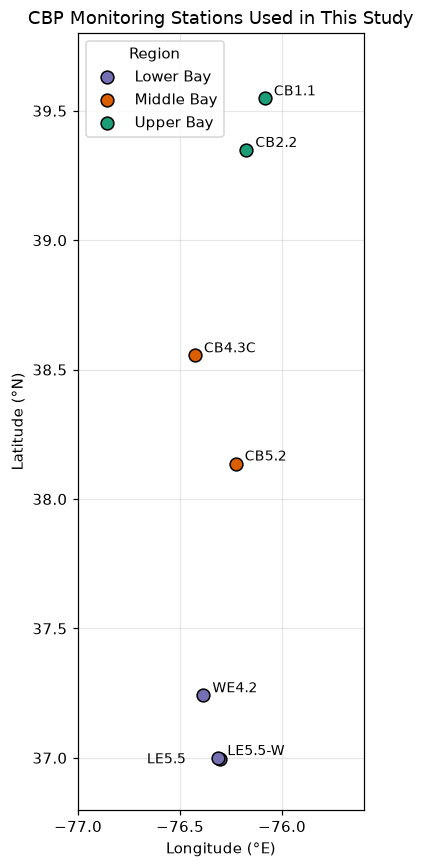

In [11]:
# Mapping the 7 stations in the Bay
colors = {'Upper Bay': '#1b9e77', 'Middle Bay': '#d95f02', 'Lower Bay': '#7570b3'}
fig, ax = plt.subplots(figsize=(6, 8))
for region, g in stations.groupby('Region'):
    ax.scatter(g['Longitude'], g['Latitude'], s=70, color=colors[region], label=region,
               edgecolor='k', zorder=3)
for _, r in stations.iterrows():
    off = (-48, -3) if r['Station'] == 'LE5.5' else (6, 2)
    ax.annotate(r['Station'], (r['Longitude'], r['Latitude']), xytext=off,
                textcoords='offset points', fontsize=9)
ax.set_xlim(-77.0, -75.6)
ax.set_ylim(36.8, 39.8)
ax.set_title('CBP Monitoring Stations Used in This Study')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_aspect(1 / np.cos(np.deg2rad(38)))
ax.grid(alpha=0.3)
ax.legend(title='Region', loc='upper left')
ax.set_xticks([-77.0, -76.5, -76.0])
plt.tight_layout()
plt.show()

### Temporal range and sampling frequency

Both programs began in the mid-1980s and sample on fixed cruise schedules: about monthly in winter and twice monthly in spring and summer during the early years, dropping to roughly monthly at most stations after the mid-1990s. Water quality sampling continues through 2026 at the Lower Bay stations, while phytoplankton counts at the Upper and Middle Bay stations end in 2019. LE5.5 sampling ended in 1996; the station was later moved and renamed LE5.5-W, which begins in 2003 for water quality and 2004 for phytoplankton, leaving a gap of about seven years at that site.

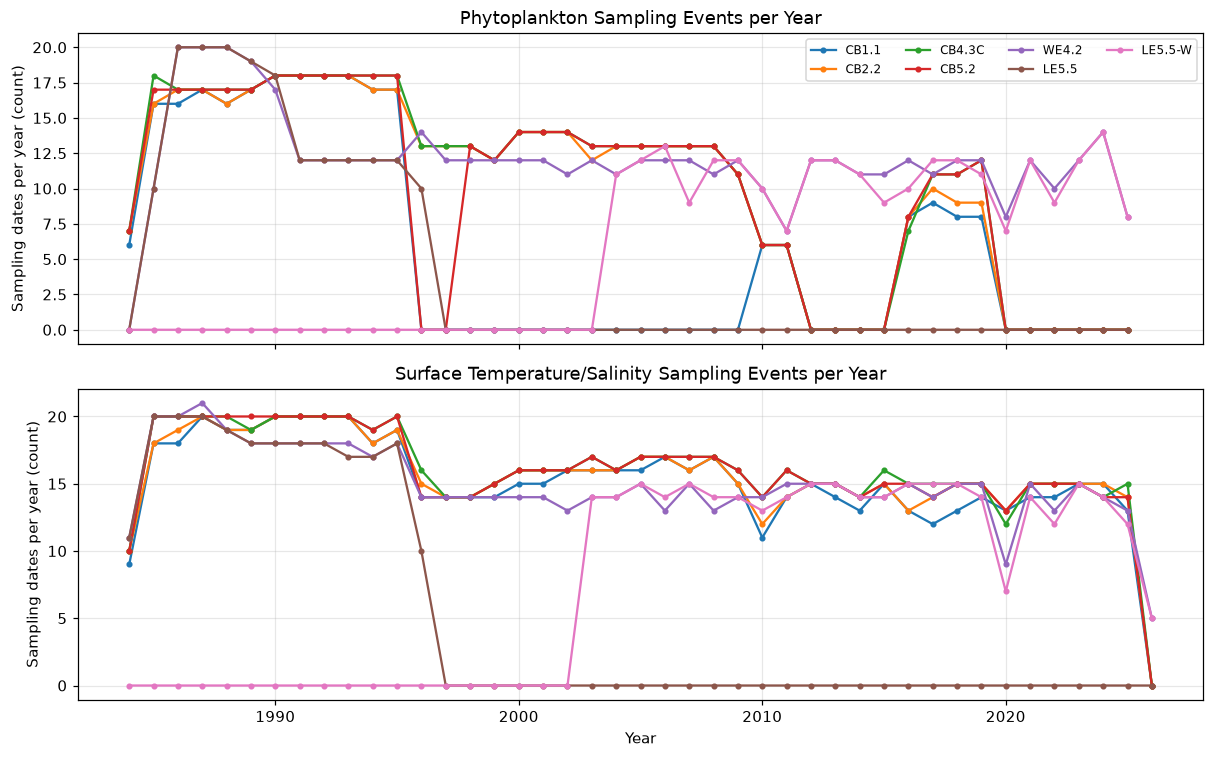

In [12]:
# Plot the number of sampling dates per year at each station for both datasets. Sampling was more frequent in the 1980s-early 1990s, Upper/Middle Bay phytoplankton stops after 2019, and LE5.5 stops in 1996.
def per_year(d):
    d = d.copy()
    d['Year'] = pd.to_datetime(d['SampleDate']).dt.year
    return d.groupby(['Station', 'Year']).size().unstack('Station', fill_value=0)

p_year = per_year(phyto_events)
t_year = per_year(ts_wide)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, tab, title in [(axes[0], p_year, 'Phytoplankton Sampling Events per Year'),
                       (axes[1], t_year, 'Surface Temperature/Salinity Sampling Events per Year')]:
    for st in STATIONS:
        if st in tab:
            ax.plot(tab.index, tab[st], marker='o', ms=3, label=st)
    ax.set_title(title)
    ax.set_ylabel('Sampling dates per year (count)')
    ax.grid(alpha=0.3)
axes[1].set_xlabel('Year')
axes[0].legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

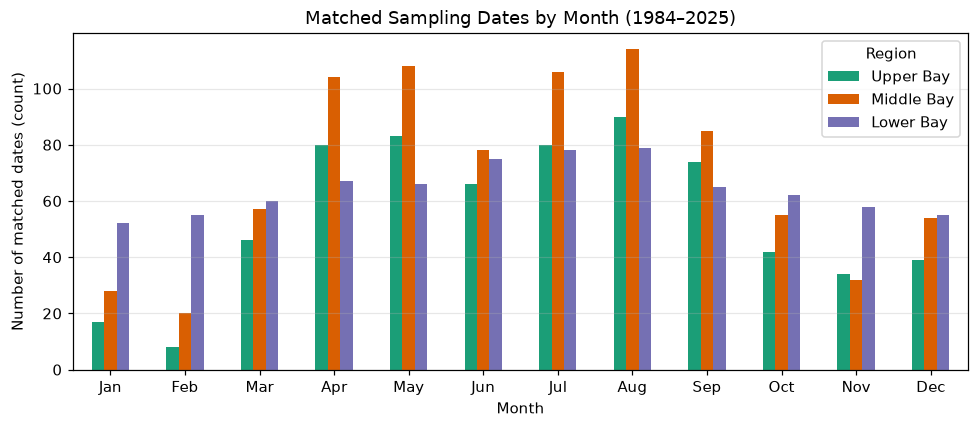

In [13]:
# Count matched sampling dates by month and region. Samples are most common April-September and fewest in January-February,
# so winter has the fewest observations (~80-100 per month across all stations).
month_counts = df.groupby(['Month', 'Region']).size().unstack('Region').reindex(columns=colors.keys())
ax = month_counts.plot(kind='bar', figsize=(9, 4), color=[colors[c] for c in month_counts.columns])
ax.set_title('Matched Sampling Dates by Month (1984–2025)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of matched dates (count)')
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Data Integration and Overlap

### Spatial and temporal overlap

Spatially, the two datasets overlap completely for the six study locations, because both programs sample the same stations on the same cruises. Temporal overlap is high but not complete. Most phytoplankton samples have a temperature/salinity profile from the same day, but some dates exist in only one dataset. The largest gap is the Upper and Middle Bay stations after 2019, which have temperature and salinity data but no phytoplankton counts. The remaining phytoplankton-only dates, most common at WE4.2 in the late 1980s and early 1990s, are mostly samples collected on a different day than the water quality cruise. Dates that appear in only one dataset were dropped in the compiled table.

Status   Both  Phytoplankton only  Temp/Sal only
Station                                         
CB1.1     238                   1            415
CB2.2     421                   4            250
CB4.3C    434                   2            254
CB5.2     407                   3            278
WE4.2     367                 140            274
LE5.5     169                   8             55
LE5.5-W   236                   1             87

Share of phytoplankton dates with same-day T/S: 93.5%


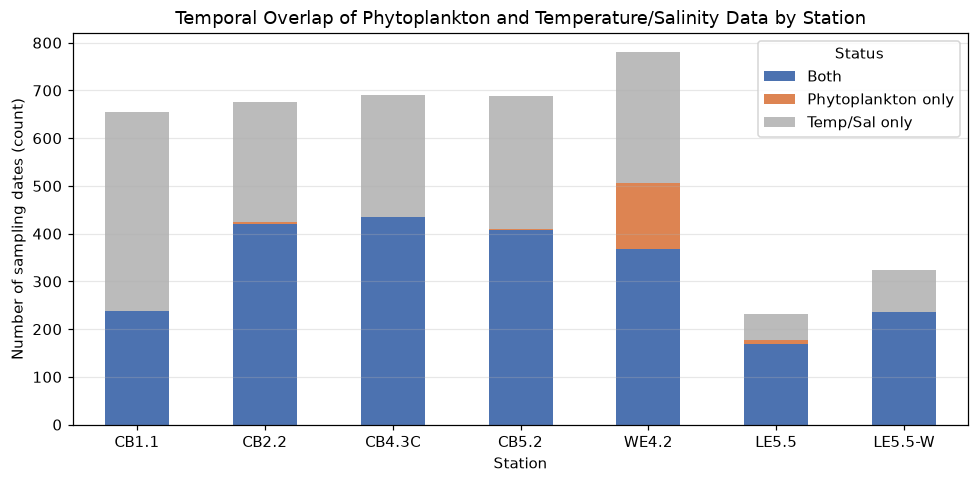

In [14]:
# Compare, for each station, dates with both datasets vs. phytoplankton only vs. T/S only.
# Most phytoplankton dates have same-day T/S data
p_keys = phyto_events[['Station', 'SampleDate']].assign(phyto=True)
t_keys = ts_wide[['Station', 'SampleDate']].assign(ts=True)
overlap = p_keys.merge(t_keys, on=['Station', 'SampleDate'], how='outer')
overlap['Status'] = np.select(
    [overlap['phyto'].notna() & overlap['ts'].notna(), overlap['phyto'].notna()],
    ['Both', 'Phytoplankton only'], 'Temp/Sal only')

ov = overlap.groupby(['Station', 'Status']).size().unstack(fill_value=0).reindex(STATIONS)
ov = ov[['Both', 'Phytoplankton only', 'Temp/Sal only']]
print(ov)
print(f"\nShare of phytoplankton dates with same-day T/S: {ov['Both'].sum() / (ov['Both'].sum() + ov['Phytoplankton only'].sum()):.1%}")

ax = ov.plot(kind='bar', stacked=True, figsize=(9, 4.5), color=['#4c72b0', '#dd8452', '#bbbbbb'])
ax.set_title('Temporal Overlap of Phytoplankton and Temperature/Salinity Data by Station')
ax.set_xlabel('Station')
ax.set_ylabel('Number of sampling dates (count)')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Compatibility and resolution alignment

- Spatial: Same stations and coordinates in both datasets, so no spatial interpolation is needed.
- Temporal: Both are discrete samples from the same cruises. I matched records on exact station and date. A small number of phytoplankton samples have a T/S profile one or two days away; these were excluded rather than matched to a nearby date.
- Vertical: This is the main resolution mismatch. Temperature and salinity are point measurements at 0.5–1 m, while phytoplankton samples are composites over the water column above the pycnocline (or the whole water column at the shallow Upper Bay stations). The surface T/S value is used as the best available descriptor of the conditions those cells experienced.
- Units: Temperature (°C) and salinity (ppt) are consistent across the record. Phytoplankton abundance is in cells/L throughout, after treating the 2013–2021 records labeled `L` as cells/L.
- Methods: Counting methods and labs changed over time and differ between the Maryland and Virginia programs, which may affect comparability of absolute cell counts between regions and decades. This will be considered in later analysis.

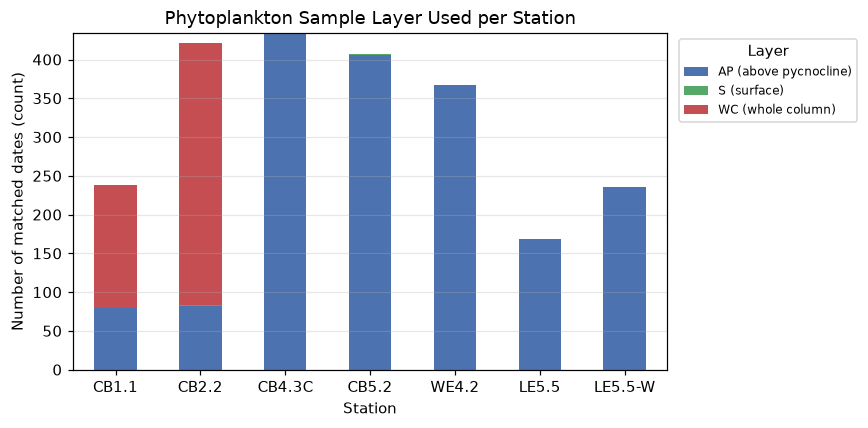

In [15]:
# Show which phytoplankton sample type was used at each station: CB1.1 and CB2.2 rely mostly on whole-water-column samples,
# while all other stations use above-pycnocline samples.
fig, ax = plt.subplots(figsize=(8, 4))
layer_counts = df.groupby(['Station', 'Phyto_Layer']).size().unstack(fill_value=0).reindex(STATIONS)
layer_counts.plot(kind='bar', stacked=True, ax=ax, color=['#4c72b0', '#55a868', '#c44e52'][:layer_counts.shape[1]])
ax.set_title('Phytoplankton Sample Layer Used per Station')
ax.set_xlabel('Station')
ax.set_ylabel('Number of matched dates (count)')
ax.legend(['AP (above pycnocline)', 'S (surface)', 'WC (whole column)'], title='Layer', fontsize=8,
          bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Visualizations

The figures below analyze the compiled surface dataset - time series of temperature and salinity data and phytoplankton abundance by station/region

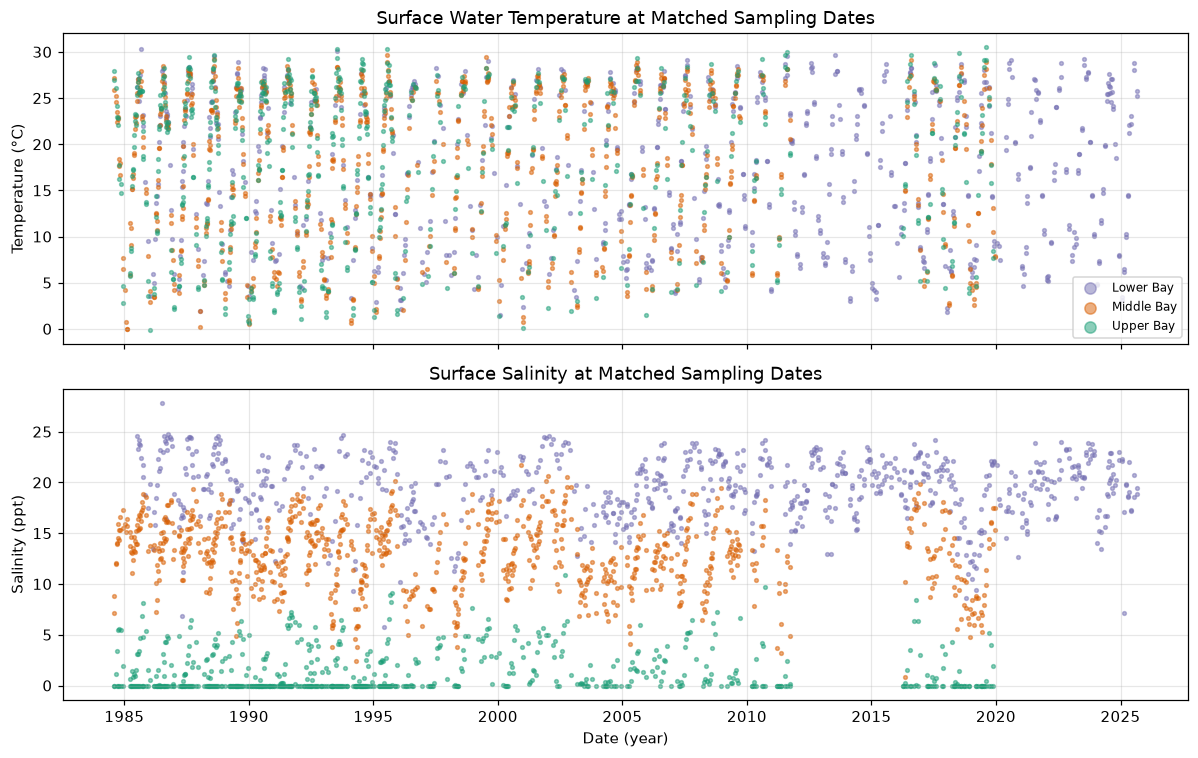

In [16]:
# Plot surface temperature and salinity at matched dates over time.
# Shows the seasonal temperature cycle and the strong salinity gradient from ~0 ppt (Upper Bay) to ~20 ppt (Lower Bay).
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for region, g in df.groupby('Region'):
    axes[0].scatter(g['SampleDate'], g['Temperature_C'], s=6, alpha=0.5, color=colors[region], label=region)
    axes[1].scatter(g['SampleDate'], g['Salinity_ppt'], s=6, alpha=0.5, color=colors[region], label=region)
axes[0].set_title('Surface Water Temperature at Matched Sampling Dates')
axes[0].set_ylabel('Temperature (°C)')
axes[1].set_title('Surface Salinity at Matched Sampling Dates')
axes[1].set_ylabel('Salinity (ppt)')
axes[1].set_xlabel('Date (year)')
for ax in axes:
    ax.grid(alpha=0.3)
axes[0].legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

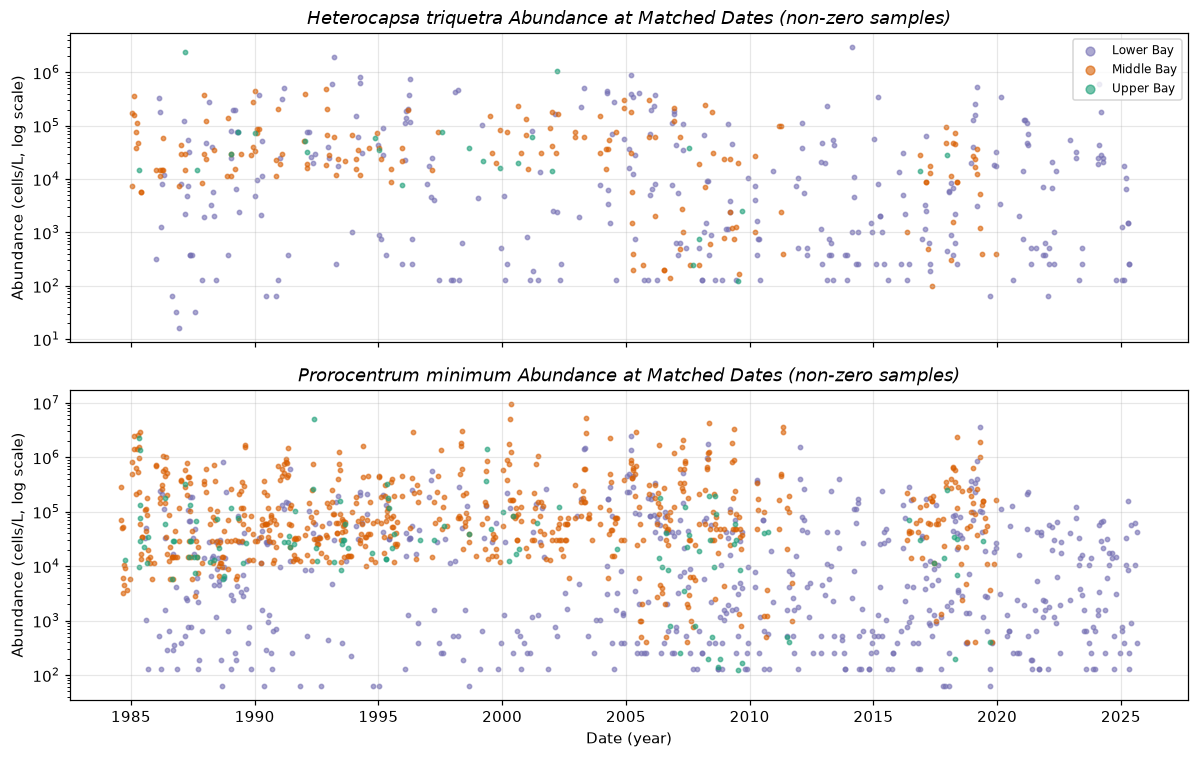

In [17]:
# Plot every sample where each species was present over the full record (log scale).
# P. minimum is found far more often than H. triquetra, and both regularly reach 10^5-10^6 cells/L.
species = [('H_triquetra_cells_L', 'Heterocapsa triquetra'), ('P_minimum_cells_L', 'Prorocentrum minimum')]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, (col, name) in zip(axes, species):
    for region, g in df.groupby('Region'):
        pos = g[g[col] > 0]
        ax.scatter(pos['SampleDate'], pos[col], s=8, alpha=0.6, color=colors[region], label=region)
    ax.set_yscale('log')
    ax.set_title(f'{name} Abundance at Matched Dates (non-zero samples)', style='italic')
    ax.set_ylabel('Abundance (cells/L, log scale)')
    ax.grid(alpha=0.3)
axes[1].set_xlabel('Date (year)')
axes[0].legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

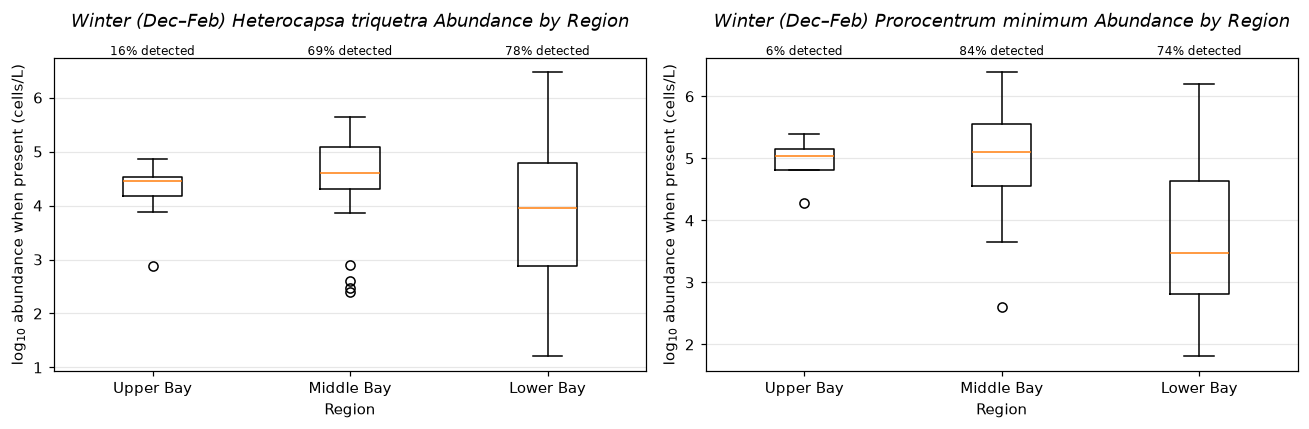

In [18]:
# Winter (Dec-Feb) abundance by region. Both species are rare in the fresh Upper Bay (16% and 6% of samples)
# but common in the Middle and Lower Bay, with the highest winter abundances in the Middle Bay.
winter = df[df['Season'] == 'Winter']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
regions = list(colors)
for ax, (col, name) in zip(axes, species):
    data = [np.log10(winter.loc[(winter['Region'] == r) & (winter[col] > 0), col]) for r in regions]
    ax.boxplot(data)
    ax.set_xticks(range(1, len(regions) + 1))
    ax.set_xticklabels(regions)
    pct = [(winter.loc[winter['Region'] == r, col] > 0).mean() * 100 for r in regions]
    for i, p in enumerate(pct, start=1):
        ax.text(i, ax.get_ylim()[1], f'{p:.0f}% detected', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'Winter (Dec–Feb) {name} Abundance by Region\n', style='italic')
    ax.set_xlabel('Region')
    ax.set_ylabel('log$_{10}$ abundance when present (cells/L)')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Summary and Next Steps

The compiled surface dataset combines CBP phytoplankton counts and surface temperature/salinity for six locations (seven station codes) from 1984 to 2026, restricted to dates with both data types.
Both datasets share the same stations, so spatial overlap is complete. Temporal overlap is high, but phytoplankton counts end in 2019 at the Upper and Middle Bay stations, and the LE5.5 site has a gap from 1996 until LE5.5-W begins in 2003–2004.
Next steps: define a bloom threshold for each species, compare bloom conditions across regions and seasons, and examine long-term trends in winter temperature and bloom timing.